# CMV Winning Arguments — Triple-Encoding Longformer Classifier

Implements Option 2: instead of encoding winner and loser separately and comparing scores, both arguments are encoded together in a single forward pass as `[OP | WINNER | LOSER]`. The model reads both arguments in context and outputs a single binary judgment. This eliminates the length-as-feature problem that caused the separate-encoding approach to trivially learn 'shorter = winner'.

## 0. Installs & Imports

In [5]:
!pip install -q convokit transformers torch scikit-learn matplotlib seaborn accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.9/240.9 kB 11.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.6 MB/s eta 0:00:00


The block below was generated using Claude. 

In [ ]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    LongformerModel,
    get_cosine_schedule_with_warmup,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, confusion_matrix,
)
import convokit
from convokit import Corpus, download

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = 'allenai/longformer-base-4096'

# With triple encoding (OP + winner + loser in one sequence), we need
# more tokens. 2048 fits most pairs; raise if your GPU allows.
MAX_LENGTH = 2048
BATCH_SIZE = 8
VAL_SIZE   = 0.10
TEST_SIZE  = 0.10
OUTPUT_DIR = Path('checkpoints')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : NVIDIA A100-SXM4-80GB
VRAM     : 85.1 GB


## 1. Data Loading & Splitting

Identical extraction to the separate-encoding notebook. The key difference comes in Section 3 where both arguments are encoded together. Pairs are randomly swapped (winner/loser position randomised) so the model cannot learn a positional bias.

The block below was generated using Claude. 

In [7]:
SPLIT_DIR = Path('data/splits')

URL_RE   = re.compile(r'https?://\S+|www\.\S+')
EDIT_RE  = re.compile(r'\bEDIT\b.*', re.IGNORECASE | re.DOTALL)
MULTI_NL = re.compile(r'\n{3,}')
MULTI_SP = re.compile(r' {2,}')

def clean_text(text: str) -> str:
    text = EDIT_RE.sub('', text)
    text = URL_RE.sub('[URL]', text)
    text = MULTI_NL.sub('\n\n', text)
    text = MULTI_SP.sub(' ', text)
    return text.strip()

if (SPLIT_DIR / 'train.csv').exists():
    print('Loading splits from CSV cache...')
    df_train = pd.read_csv(SPLIT_DIR / 'train.csv')
    df_val   = pd.read_csv(SPLIT_DIR / 'val.csv')
    df_test  = pd.read_csv(SPLIT_DIR / 'test.csv')
else:
    print('Extracting from ConvoKit corpus...')
    corpus = Corpus(filename=download('winning-args-corpus'))

    op_texts = {}
    for utt in corpus.iter_utterances():
        if utt.reply_to is None:
            op_texts[utt.conversation_id] = clean_text(utt.text or '')

    pairs = {}
    for utt in corpus.iter_utterances():
        pair_ids = utt.meta.get('pair_ids')
        if not pair_ids:
            continue
        pid     = pair_ids[0]
        success = utt.meta.get('success')
        text    = (utt.text or '').strip()
        if not text or success is None:
            continue
        if pid not in pairs:
            pairs[pid] = {}
        role = 'winner' if success == 1 else 'loser'
        pairs[pid][role] = {
            'id'      : utt.id,
            'text'    : clean_text(text),
            'conv_id' : utt.conversation_id,
        }

    records = []
    for pid, p in pairs.items():
        if 'winner' not in p or 'loser' not in p:
            continue
        conv_id = p['winner']['conv_id']
        if (len(p['winner']['text'].split()) < 5 or
                len(p['loser']['text'].split()) < 5):
            continue
        records.append({
            'pair_id' : pid,
            'conv_id' : conv_id,
            'op_text' : op_texts.get(conv_id, ''),
            'pos_text': p['winner']['text'],
            'neg_text': p['loser']['text'],
            'pos_wc'  : len(p['winner']['text'].split()),
            'neg_wc'  : len(p['loser']['text'].split()),
        })

    df_pairs = pd.DataFrame(records)
    print(f'Total complete pairs: {len(df_pairs):,}')

    conv_ids = df_pairs['conv_id'].unique()
    rng      = np.random.default_rng(SEED)
    rng.shuffle(conv_ids)

    n_test = int(len(conv_ids) * TEST_SIZE)
    n_val  = int(len(conv_ids) * VAL_SIZE)
    test_convs  = set(conv_ids[:n_test])
    val_convs   = set(conv_ids[n_test:n_test + n_val])
    train_convs = set(conv_ids[n_test + n_val:])

    df_train = df_pairs[df_pairs['conv_id'].isin(train_convs)].reset_index(drop=True)
    df_val   = df_pairs[df_pairs['conv_id'].isin(val_convs)].reset_index(drop=True)
    df_test  = df_pairs[df_pairs['conv_id'].isin(test_convs)].reset_index(drop=True)

    SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    df_train.to_csv(SPLIT_DIR / 'train.csv', index=False)
    df_val.to_csv(SPLIT_DIR / 'val.csv',     index=False)
    df_test.to_csv(SPLIT_DIR / 'test.csv',   index=False)

for df_ in [df_train, df_val, df_test]:
    df_['op_text'] = df_['op_text'].fillna('')

for name, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'{name:5s}: {len(d):,} pairs')

# Sanity checks
train_pairs = set(df_train['pair_id'])
val_pairs   = set(df_val['pair_id'])
test_pairs  = set(df_test['pair_id'])
print(f'Train/val pair overlap  : {len(train_pairs & val_pairs)}')
print(f'Train/test pair overlap : {len(train_pairs & test_pairs)}')
print(f'Mean pos_wc: {df_train["pos_wc"].mean():.1f} | Mean neg_wc: {df_train["neg_wc"].mean():.1f}')

Extracting from ConvoKit corpus...
No configuration file found at /root/.convokit/config.yml; writing with contents: 
# Default Backend Parameters
db_host: localhost:27017
data_directory: ~/.convokit/saved-corpora
model_directory: ~/.convokit/saved-models
default_backend: mem
Total complete pairs: 3,763
Train: 3,015 pairs
Val  : 384 pairs
Test : 364 pairs
Train/val pair overlap  : 0
Train/test pair overlap : 0
Mean pos_wc: 91.2 | Mean neg_wc: 161.3


## 2. Baseline Models

The block below was generated using Claude. 

In [ ]:
baseline_results = {}
baseline_results['Random'] = {'Accuracy': 0.5, 'ROC-AUC': float('nan')}

shorter_wins = (df_test['pos_wc'] < df_test['neg_wc']).astype(int)
baseline_results['Shorter wins'] = {'Accuracy': float(shorter_wins.mean())}

print(f'Random baseline   | Accuracy: 0.5000')
print(f'Shorter-wins      | Accuracy: {shorter_wins.mean():.4f}')

Random baseline   | Accuracy: 0.5000
Shorter-wins      | Accuracy: 0.6951


The block below was generated using Claude. 

In [20]:
# TF-IDF + LR: trained on individual texts, evaluated pairwise
tfidf = TfidfVectorizer(max_features=50_000, sublinear_tf=True, ngram_range=(1, 2))
tfidf.fit(pd.concat([df_train['pos_text'], df_train['neg_text']]).tolist())

X_tr = tfidf.transform(
    pd.concat([df_train['pos_text'], df_train['neg_text']]).tolist()
)
y_tr = np.array([1] * len(df_train) + [0] * len(df_train))
lr_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
lr_clf.fit(X_tr, y_tr)

def pairwise_tfidf_eval(df, tfidf, clf):
    s_pos   = clf.predict_proba(tfidf.transform(df['pos_text']))[:, 1]
    s_neg   = clf.predict_proba(tfidf.transform(df['neg_text']))[:, 1]
    margins = s_pos - s_neg
    preds   = (margins > 0).astype(int)
    roc_auc = roc_auc_score(preds, np.abs(margins)) if len(np.unique(preds)) > 1 else float('nan')
    return preds, margins, roc_auc

preds_lr, margins_lr, auc_lr = pairwise_tfidf_eval(df_test, tfidf, lr_clf)
baseline_results['TF-IDF + LR'] = {'Accuracy': float(preds_lr.mean()), 'ROC-AUC': auc_lr}
print(f'TF-IDF + LR       | Accuracy: {preds_lr.mean():.4f} | ROC-AUC: {auc_lr:.4f}')
print('NOTE: TF-IDF accuracy is inflated by length signal (winners are shorter on average)')

# Length-matched subset for fair comparison
similar_mask = (df_test['pos_wc'] / df_test['neg_wc']).between(0.8, 1.2)
similar_idx  = df_test[similar_mask].index
print(f'TF-IDF on length-matched pairs ({len(similar_idx)}): {preds_lr[similar_idx].mean():.4f}')

TF-IDF + LR       | Accuracy: 0.9396 | ROC-AUC: 0.8594
NOTE: TF-IDF accuracy is inflated by length signal (winners are shorter on average)
TF-IDF on length-matched pairs (43): 1.0000


## 3. CMVTripleDataset — PyTorch Dataset

**Option 2 — triple encoding:** Both arguments are packed into a single sequence as:
```
<s> OP </s></s> ARG_A </s></s> ARG_B </s>
```
The label is 0 if ARG_A is the winner, 1 if ARG_B is the winner.

**Position randomisation:** Winner and loser positions are randomly swapped per sample during training. This prevents the model from learning a positional bias (e.g. 'first argument always wins'). At test time positions are fixed (winner always first) for consistent evaluation.

**Why this fixes the length problem:** Both arguments appear in the same sequence, so padding length is the same for both. The model cannot use sequence length to distinguish them — it must read the content.

The block below was generated using Claude. 

In [8]:
class CMVTripleDataset(Dataset):
    """
    Encodes (OP, ARG_A, ARG_B) as a single sequence.
    Label = 0 if ARG_A is the winner, 1 if ARG_B is the winner.

    During training, winner/loser positions are randomly swapped so
    the model cannot learn a positional shortcut.
    """

    def __init__(self, dataframe, tokenizer, max_length=MAX_LENGTH,
                 randomise_order=True, seed=SEED):
        self.pos_texts      = dataframe['pos_text'].tolist()   # winner
        self.neg_texts      = dataframe['neg_text'].tolist()   # loser
        self.op_texts       = dataframe['op_text'].tolist()
        self.tokenizer      = tokenizer
        self.max_length     = max_length
        self.randomise_order = randomise_order
        self.rng            = np.random.default_rng(seed)

    def __len__(self):
        return len(self.pos_texts)

    def __getitem__(self, idx):
        winner = self.pos_texts[idx]
        loser  = self.neg_texts[idx]
        op     = self.op_texts[idx]

        # Randomly swap positions during training to prevent positional bias
        if self.randomise_order and self.rng.random() > 0.5:
            arg_a, arg_b, label = loser, winner, 1   # winner is second
        else:
            arg_a, arg_b, label = winner, loser, 0   # winner is first

        # Pack as: OP [SEP] ARG_A [SEP] ARG_B
        # Longformer uses </s></s> as the separator between sequence pairs;
        # for the third segment we manually concatenate with a separator token.
        combined_b = arg_a + ' </s> ' + arg_b

        enc = self.tokenizer(
            op,
            combined_b,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        # Global attention on CLS token
        global_attn = torch.zeros_like(enc['input_ids'])
        global_attn[:, 0] = 1
        enc['global_attention_mask'] = global_attn

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['label'] = torch.tensor(label, dtype=torch.long)
        return item


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Longformer tokenizer loaded.')

# Verify a sample encoding
sample_ds  = CMVTripleDataset(df_train.head(1), tokenizer, randomise_order=False)
sample_enc = sample_ds[0]
n_real     = sample_enc['attention_mask'].sum().item()
print(f'Sample encoding: {n_real} real tokens out of {MAX_LENGTH} max')

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Longformer tokenizer loaded.
Sample encoding: 492 real tokens out of 2048 max


## 4. Model & Training Infrastructure

The architecture is now a **binary classifier** (CrossEntropyLoss, label=0 means first arg wins, label=1 means second arg wins). MarginRankingLoss is no longer needed because both arguments are in the same forward pass.

### 4.1 Model Architecture

The block below was originally written by the project author for Deberta, and was converted to longformer using Claude. 

In [9]:
class LongformerTripleClassifier(nn.Module):
    """
    Binary classifier over (OP, ARG_A, ARG_B) triples.
    Output logits[0] = score for ARG_A winning.
    Output logits[1] = score for ARG_B winning.
    """

    def __init__(self, model_name, dropout=0.1):
        super().__init__()
        self.longformer = LongformerModel.from_pretrained(model_name)
        hidden_size     = self.longformer.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, 2)
        nn.init.normal_(self.classifier.weight, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask, global_attention_mask=None,
                token_type_ids=None, label=None):
        out = self.longformer(
            input_ids=input_ids,
            attention_mask=attention_mask,
            global_attention_mask=global_attention_mask,
        )
        # Mean pool over non-padding tokens
        hidden = out.last_hidden_state
        mask   = attention_mask.unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return type('Output', (), {'logits': logits})()


def build_model():
    model     = LongformerTripleClassifier(MODEL_NAME).float().to(DEVICE)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Trainable params: {trainable:,}')
    return model

### 4.2 DataLoaders

In [ ]:
def build_loaders(df_tr, df_va, df_te, tokenizer, batch_size=BATCH_SIZE):
    # Randomise order only during training
    train_ds = CMVTripleDataset(df_tr, tokenizer, randomise_order=True)
    val_ds   = CMVTripleDataset(df_va, tokenizer, randomise_order=False)
    test_ds  = CMVTripleDataset(df_te, tokenizer, randomise_order=False)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=torch.cuda.is_available(),
        persistent_workers=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=torch.cuda.is_available(),
        persistent_workers=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=torch.cuda.is_available(),
        persistent_workers=True,
    )
    return train_loader, val_loader, test_loader

### 4.3 Evaluation Helper

At eval time winner is always in position A (label=0), so accuracy = fraction predicted as label 0. ROC-AUC uses the probability of label 0 (first arg wins) as the score.

In [ ]:
def evaluate(model, loader, loss_fn):
    """Return accuracy, ROC-AUC, predictions and probabilities."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids   = batch['input_ids'].to(DEVICE)
            attn_mask   = batch['attention_mask'].to(DEVICE)
            gattn       = batch.get('global_attention_mask')
            if gattn is not None:
                gattn = gattn.to(DEVICE)
            labels      = batch['label'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attn_mask,
                global_attention_mask=gattn,
            )
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            probs = torch.softmax(outputs.logits, dim=-1)
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.tolist())
            # Probability of label=0 (first arg wins) as the positive score
            all_probs.extend(probs[:, 0].cpu().numpy().tolist())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)   # P(A wins) = P(winner is first)

    correct = (all_preds == all_labels)

    # code below generated by Claude

    # All eval labels are 0 (winner always in position A).
    # AUC: does higher P(A wins) correlate with being correct?
    # correct=1 where model predicted 0, correct=0 where model predicted 1.
    # Use P(A wins) as score against correctness.
    roc_auc = roc_auc_score(correct.astype(int), all_probs) \
        if len(np.unique(correct)) > 1 else float('nan')
    return {
        'loss'    : total_loss / len(loader),
        'accuracy': correct.mean(),
        'roc_auc' : roc_auc,
        'labels'  : all_labels,
        'preds'   : all_preds,
        'probs'   : all_probs,
        'correct' : correct.astype(int),
    }

### 4.4 Training Loop

The block below was originally written by the user, but later modified using heavy assistance from Claude after change in base model. 

In [12]:
def train_model(run_name, lr, num_epochs=5, save_best=True, model=None):

    print(f'\n{"="*60}')
    print(f'RUN: {run_name} | LR={lr}')
    print(f'{"="*60}')

    train_loader, val_loader, test_loader = build_loaders(
        df_train, df_val, df_test, tokenizer,
    )

    if model is None:
        model = build_model()

    loss_fn = nn.CrossEntropyLoss()
    scaler  = torch.cuda.amp.GradScaler()

    optimizer = torch.optim.AdamW([
        {'params': model.longformer.parameters(),  'lr': lr},
        {'params': model.classifier.parameters(),  'lr': lr},
    ], weight_decay=0.01, eps=1e-6)

    total_steps  = len(train_loader) * num_epochs
    warmup_steps = len(train_loader)   # 1 full epoch warmup
    print(f'Loader size  : {len(train_loader)} | Total steps: {total_steps}')
    print(f'Warmup steps : {warmup_steps} | Peak LR at end of epoch 1')

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'val_accuracy': [], 'val_roc_auc': [], 'lr': [],
    }

    best_val_acc = -1
    best_epoch   = -1
    no_improve   = 0
    patience     = 3
    best_ckpt    = OUTPUT_DIR / f'{run_name}_best.pt'

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0

        for step, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            gattn     = batch.get('global_attention_mask')
            if gattn is not None:
                gattn = gattn.to(DEVICE)
            labels    = batch['label'].to(DEVICE)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attn_mask,
                    global_attention_mask=gattn,
                )
                loss = loss_fn(outputs.logits, labels)

            epoch_loss += loss.item()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            if (step + 1) % 100 == 0:
                print(
                    f'Epoch {epoch} | Step {step+1}/{len(train_loader)} | '
                    f'Loss: {epoch_loss/(step+1):.4f} | LR: {scheduler.get_last_lr()[0]:.2e}'
                )

        avg_train_loss = epoch_loss / len(train_loader)
        val_metrics    = evaluate(model, val_loader, loss_fn)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['val_roc_auc'].append(val_metrics['roc_auc'])
        history['lr'].append(scheduler.get_last_lr()[0])

        print(
            f'Epoch {epoch} SUMMARY | Train Loss: {avg_train_loss:.4f} | '
            f'Val Loss: {val_metrics["loss"]:.4f} | '
            f'Val Accuracy: {val_metrics["accuracy"]:.4f} | '
            f'Val ROC-AUC: {val_metrics["roc_auc"]:.4f}'
        )

        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
            no_improve   = 0
            # Only save if accuracy is meaningfully above the trivial baseline
            # (epoch 1's 1.0 is a degenerate all-zeros prediction, not real learning)
            if save_best and val_metrics['accuracy'] < 0.99:
                torch.save(model.state_dict(), best_ckpt)
                print(f'  ✓ New best val accuracy: {best_val_acc:.4f}')
                best_epoch   = epoch
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

    print(f'\nBest epoch: {best_epoch} | Best val accuracy: {best_val_acc:.4f}')

    if save_best and best_ckpt.exists():
        model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))

    test_metrics = evaluate(model, test_loader, loss_fn)
    print(f'Test Accuracy: {test_metrics["accuracy"]:.4f} | Test ROC-AUC: {test_metrics["roc_auc"]:.4f}')

    return history, test_metrics, model

## 5. Hyperparameter Tuning — Learning Rate Search

The block below was generated using Claude. 

In [16]:
lr_candidates     = [5e-6, 1e-5, 2e-5]
lr_search_results = {}

for lr in lr_candidates:
    torch.cuda.empty_cache()
    model_tmp = build_model()
    history, _, _ = train_model(
        run_name=f'lr_search_{lr:.0e}',
        lr=lr,
        num_epochs=4,
        save_best=False,
        model=model_tmp,
    )
    lr_search_results[lr] = {
        'best_val_accuracy': max(history['val_accuracy']),
        'best_val_roc_auc' : max(h for h in history['val_roc_auc'] if not np.isnan(h)),
    }
    del model_tmp

print('\n=== LR SEARCH RESULTS ===')
print(f'{"LR":>10s} | {"Best Val Accuracy":>18s} | {"Best Val ROC-AUC":>16s}')
print('-' * 50)
for lr, res in lr_search_results.items():
    print(f'{lr:>10.0e} | {res["best_val_accuracy"]:>18.4f} | {res["best_val_roc_auc"]:>16.4f}')

BEST_LR = max(lr_search_results, key=lambda lr: lr_search_results[lr]['best_val_accuracy'])
print(f'\nSelected LR: {BEST_LR:.0e}')

Loading weights:   0%|          | 0/271 [00:00<?, ?it/s]

LongformerModel LOAD REPORT from: allenai/longformer-base-4096
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 148,660,994

RUN: lr_search_5e-06 | LR=5e-06
Loader size  : 377 | Total steps: 1508
Warmup steps : 377 | Peak LR at end of epoch 1
Epoch 1 | Step 100/377 | Loss: 0.7008 | LR: 1.33e-06
Epoch 1 | Step 200/377 | Loss: 0.7006 | LR: 2.65e-06
Epoch 1 | Step 300/377 | Loss: 0.6997 | LR: 3.98e-06
Epoch 1 SUMMARY | Train Loss: 0.6994 | Val Loss: 0.6524 | Val Accuracy: 0.9557 | Val ROC-AUC: 1.0000
Epoch 2 | Step 100/377 | Loss: 0.6920 | LR: 4.90e-06
Epoch 2 | Step 200/377 | Loss: 0.6547 | LR: 4.62e-06
Epoch 2 | Step 300/377 | Loss: 0.5500 | LR: 4.18e-06
Epoch 2 SUMMARY | Train Loss: 0.4987 | Val Loss: 0.1445 | Val Accuracy: 0.9505 | Val ROC-AUC: 1.0000
Epoch 3 | Step 100/377 | Loss: 0.2445 | LR: 3.11e-06
Epoch 3 | Step 200/377 | Loss: 0.2393 | LR: 2.42e-06
Epoch 3 | Step 300/377 | Loss: 0.2323 | LR: 1.74e-06
Epoch 3 SUMMARY | Train Loss: 0.2286 | Val Loss: 0.0622 | Val Accuracy: 0.9844 | Val ROC-AUC: 1.0000
Epoch 4 | Step 100/377 | Loss: 0.1510 | LR: 7.04e-07
Epoch 4 | Step 200

Loading weights:   0%|          | 0/271 [00:00<?, ?it/s]

LongformerModel LOAD REPORT from: allenai/longformer-base-4096
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 148,660,994

RUN: lr_search_1e-05 | LR=1e-05
Loader size  : 377 | Total steps: 1508
Warmup steps : 377 | Peak LR at end of epoch 1
Epoch 1 | Step 100/377 | Loss: 0.7035 | LR: 2.65e-06
Epoch 1 | Step 200/377 | Loss: 0.7024 | LR: 5.31e-06
Epoch 1 | Step 300/377 | Loss: 0.7032 | LR: 7.96e-06
Epoch 1 SUMMARY | Train Loss: 0.7035 | Val Loss: 0.6007 | Val Accuracy: 1.0000 | Val ROC-AUC: nan
Epoch 2 | Step 100/377 | Loss: 0.6266 | LR: 9.81e-06
Epoch 2 | Step 200/377 | Loss: 0.5596 | LR: 9.25e-06
Epoch 2 | Step 300/377 | Loss: 0.5047 | LR: 8.36e-06
Epoch 2 SUMMARY | Train Loss: 0.4518 | Val Loss: 0.1498 | Val Accuracy: 0.9661 | Val ROC-AUC: 1.0000
Epoch 3 | Step 100/377 | Loss: 0.2678 | LR: 6.22e-06
Epoch 3 | Step 200/377 | Loss: 0.2116 | LR: 4.84e-06
Epoch 3 | Step 300/377 | Loss: 0.1920 | LR: 3.48e-06
Epoch 3 SUMMARY | Train Loss: 0.1850 | Val Loss: 0.2488 | Val Accuracy: 0.9505 | Val ROC-AUC: 1.0000
Epoch 4 | Step 100/377 | Loss: 0.1694 | LR: 1.41e-06
Epoch 4 | Step 200/37

Loading weights:   0%|          | 0/271 [00:00<?, ?it/s]

LongformerModel LOAD REPORT from: allenai/longformer-base-4096
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 148,660,994

RUN: lr_search_2e-05 | LR=2e-05
Loader size  : 377 | Total steps: 1508
Warmup steps : 377 | Peak LR at end of epoch 1
Epoch 1 | Step 100/377 | Loss: 0.7065 | LR: 5.31e-06
Epoch 1 | Step 200/377 | Loss: 0.7031 | LR: 1.06e-05
Epoch 1 | Step 300/377 | Loss: 0.7035 | LR: 1.59e-05
Epoch 1 SUMMARY | Train Loss: 0.6782 | Val Loss: 0.4594 | Val Accuracy: 0.7812 | Val ROC-AUC: 1.0000
Epoch 2 | Step 100/377 | Loss: 0.3387 | LR: 1.96e-05
Epoch 2 | Step 200/377 | Loss: 0.3370 | LR: 1.85e-05
Epoch 2 | Step 300/377 | Loss: 0.3012 | LR: 1.67e-05
Epoch 2 SUMMARY | Train Loss: 0.2987 | Val Loss: 0.1356 | Val Accuracy: 0.9557 | Val ROC-AUC: 1.0000
Epoch 3 | Step 100/377 | Loss: 0.1699 | LR: 1.24e-05
Epoch 3 | Step 200/377 | Loss: 0.1641 | LR: 9.68e-06
Epoch 3 | Step 300/377 | Loss: 0.1448 | LR: 6.95e-06
Epoch 3 SUMMARY | Train Loss: 0.1446 | Val Loss: 0.1125 | Val Accuracy: 0.9766 | Val ROC-AUC: 1.0000
Epoch 4 | Step 100/377 | Loss: 0.1194 | LR: 2.82e-06
Epoch 4 | Step 200

## 6. Full Training Run — Best Configuration

In [14]:
torch.cuda.empty_cache()
history_main, test_metrics_main, model_main = train_model(
    run_name='longformer_triple_main',
    lr=BEST_LR,
    num_epochs=8,
    save_best=True,
)


RUN: longformer_triple_main | LR=1e-05


pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/271 [00:00<?, ?it/s]

LongformerModel LOAD REPORT from: allenai/longformer-base-4096
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

Trainable params: 148,660,994
Loader size  : 377 | Total steps: 3016
Warmup steps : 377 | Peak LR at end of epoch 1
Epoch 1 | Step 100/377 | Loss: 0.6972 | LR: 2.65e-06
Epoch 1 | Step 200/377 | Loss: 0.6968 | LR: 5.31e-06
Epoch 1 | Step 300/377 | Loss: 0.6976 | LR: 7.96e-06
Epoch 1 SUMMARY | Train Loss: 0.6946 | Val Loss: 0.8565 | Val Accuracy: 0.3698 | Val ROC-AUC: 1.0000
  ✓ New best val accuracy: 0.3698
Epoch 2 | Step 100/377 | Loss: 0.4190 | LR: 9.96e-06
Epoch 2 | Step 200/377 | Loss: 0.3434 | LR: 9.86e-06
Epoch 2 | Step 300/377 | Loss: 0.3102 | LR: 9.68e-06
Epoch 2 SUMMARY | Train Loss: 0.2862 | Val Loss: 0.1966 | Val Accuracy: 0.9609 | Val ROC-AUC: 1.0000
  ✓ New best val accuracy: 0.9609
Epoch 3 | Step 100/377 | Loss: 0.1628 | LR: 9.22e-06
Epoch 3 | Step 200/377 | Loss: 0.1613 | LR: 8.87e-06
Epoch 3 | Step 300/377 | Loss: 0.1390 | LR: 8.46e-06
Epoch 3 SUMMARY | Train Loss: 0.1313 | Val Loss: 0.0847 | Val Accuracy: 0.9870 | Val ROC-AUC: 1.0000
  ✓ New best val accuracy: 0.9870
Ep

## 7. Training Curves

Parts of the code below were written by Claude. 

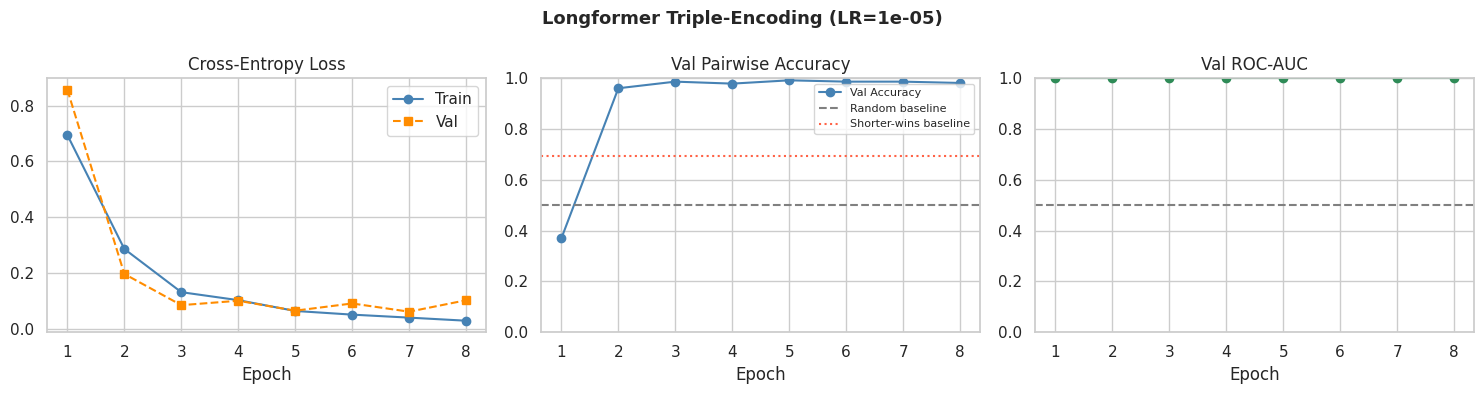

In [16]:
def plot_training_curves(history, title='Training Curves'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history['train_loss'], 'o-', label='Train', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   's--', label='Val',   color='darkorange')
    axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    axes[1].plot(epochs, history['val_accuracy'], 'o-', color='steelblue', label='Val Accuracy')
    axes[1].axhline(0.5,  color='grey',   linestyle='--', label='Random baseline')
    axes[1].axhline(0.695, color='tomato', linestyle=':', label='Shorter-wins baseline')
    axes[1].set_title('Val Pairwise Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)
    axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    axes[2].plot(epochs, history['val_roc_auc'], 'o-', color='seagreen')
    axes[2].axhline(0.5, color='grey', linestyle='--')
    axes[2].set_title('Val ROC-AUC'); axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 1)
    axes[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_curves(
    history_main,
    title=f'Longformer Triple-Encoding (LR={BEST_LR:.0e})'
)

## 8. Final Evaluation on Test Set

In [30]:
print('=== FINAL TEST SET RESULTS ===')
print(f'Baselines to beat:')
print(f'  Random        : 0.5000')
print(f'  Shorter wins  : {shorter_wins.mean():.4f}  ← length heuristic')
print(f'  TF-IDF + LR   : {preds_lr.mean():.4f}  ← lexical + length signal')
print()

all_results = {
    **baseline_results,
    'Longformer triple-encoding': {
        'Accuracy': float(test_metrics_main['accuracy']),
    },
}
print(f'{"Model":35s} | {"Accuracy":>10s}')
print('-' * 48)
for name, m in all_results.items():
    print(f'{name:35s} | {m["Accuracy"]:>10.4f}')


=== FINAL TEST SET RESULTS ===
Baselines to beat:
  Random        : 0.5000
  Shorter wins  : 0.6951  ← length heuristic
  TF-IDF + LR   : 0.9396  ← lexical + length signal

Model                               |   Accuracy
------------------------------------------------
Random                              |     0.5000
Shorter wins                        |     0.6951
TF-IDF + LR                         |     0.9396
Longformer triple-encoding          |     0.9753


## 9. Error Analysis

Pseudo-code written by the user was then implemented by Claude. 

Correct  : 355 / 364 (0.975)
Incorrect: 9 / 364

Accuracy on length-matched pairs (43 pairs): 0.9767
(random=0.50, shorter-wins=0.50 by construction on these pairs)

Accuracy by winner word count bucket:
                total  correct_n  accuracy
pos_len_bucket                            
0-50              155        153  0.987097
51-100            122        120  0.983607
101-200            62         62  1.000000
201-400            19         17  0.894737
400+                6          3  0.500000


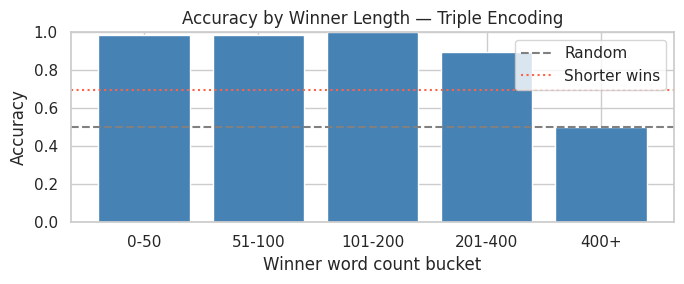


=== HARDEST PAIRS (model predicted loser wins) ===
[P(winner first)=0.000 | winner=317w loser=46w]
  WINNER: First of all thank you for being the first to answer my question rather than attack the veganism directly. Upvote to you.

&gt; The first seems like a category error. So far as we know, animals do not have language, so the notion that they have a rig
  LOSER : You make good points.

My reasons were part environmental, part health, part ethical. Any single one of those is reason enough to go vegan imo. I urge you to research the conditions of the animals (and their products) that you are consuming.

Thanks 
---
[P(winner first)=0.000 | winner=42w loser=40w]
  WINNER: I guess I overlooked the part about practicing. One cannot expect to do anything non-trivial without practicing it beforehand. And defending yourself from an attack is definitely non-trivial. 
Also, the part about instinctively getting in the right p
  LOSER : &gt; The guy in the video isn't suggesting that if you j

In [ ]:
error_df = df_test.copy()
error_df['correct'] = test_metrics_main['correct']
error_df['prob_a_wins'] = test_metrics_main['probs']   # P(A wins) = P(winner first)

wrong_df = error_df[error_df['correct'] == 0]

print(f'Correct  : {error_df["correct"].sum():,} / {len(error_df):,} ({error_df["correct"].mean():.3f})')
print(f'Incorrect: {(error_df["correct"] == 0).sum():,} / {len(error_df):,}')

# Accuracy on length-matched pairs — key metric for whether model
# learned content vs just length
similar_mask   = (error_df['pos_wc'] / error_df['neg_wc']).between(0.8, 1.2)
similar_correct = error_df[similar_mask]['correct']
print(f'\nAccuracy on length-matched pairs ({similar_mask.sum()} pairs): '
      f'{similar_correct.mean():.4f}')
print('(random=0.50, shorter-wins=0.50 by construction on these pairs)')

# Accuracy by winner length bucket
error_df['pos_len_bucket'] = pd.cut(
    error_df['pos_wc'],
    bins=[0, 50, 100, 200, 400, 10000],
    labels=['0-50', '51-100', '101-200', '201-400', '400+'],
)
error_by_length = (
    error_df.groupby('pos_len_bucket')
    .agg(total=('correct', 'count'), correct_n=('correct', 'sum'))
    .assign(accuracy=lambda d: d['correct_n'] / d['total'])
)
print('\nAccuracy by winner word count bucket:')
print(error_by_length)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(error_by_length.index.astype(str), error_by_length['accuracy'],
       color='steelblue', edgecolor='white')
ax.axhline(0.5,   color='grey',   linestyle='--', label='Random')
ax.axhline(0.695, color='tomato', linestyle=':',  label='Shorter wins')
ax.set_xlabel('Winner word count bucket')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Winner Length — Triple Encoding')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== HARDEST PAIRS (model predicted loser wins) ===')
for _, row in wrong_df.sort_values('prob_a_wins').head(3).iterrows():
    print(f'[P(winner first)={row["prob_a_wins"]:.3f} | '
          f'winner={row["pos_wc"]}w loser={row["neg_wc"]}w]')
    print(f'  WINNER: {row["pos_text"][:250]}')
    print(f'  LOSER : {row["neg_text"][:250]}')
    print('---')

## 10. Export

In [26]:
from google.colab import drive
drive.mount('/content/drive')
GDRIVE_DIR = Path('/content/drive/MyDrive/cmv_longformer_triple')
GDRIVE_DIR.mkdir(parents=True, exist_ok=True)
torch.save(model_main.state_dict(), GDRIVE_DIR / 'longformer_triple_best.pt')
tokenizer.save_pretrained(GDRIVE_DIR / 'tokenizer')
print('Saved to Drive.')

Mounted at /content/drive
Saved to Drive.


In [27]:
from google.colab import files
torch.save(model_main.state_dict(), 'longformer_triple_best.pt')
files.download('longformer_triple_best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>